# Retrieval recall@k

Does raising `top-k` fix retrieval, or is the image encoder the ceiling? For each test image we dumped the top-50 EVA-CLIP+FAISS candidate articles; here we plot how often the correct article is within the top-k.

A hit = the example's ground-truth `wikipedia_url` is among the top-k retrieved articles (URLs normalized). No content is read — the dataset labels the source article.

Populate by running `scripts/run_recall.sh` (produces `outputs/retrieval/retrieval_topk50.jsonl`).

In [1]:
import json, os, re
import matplotlib.pyplot as plt

PATH = '../outputs/retrieval/retrieval_topk100.jsonl'
assert os.path.exists(PATH), 'run scripts/run_recall.sh first'
recs = [json.loads(l) for l in open(PATH) if l.strip()]
print('examples:', len(recs))

def norm(u):
    if not u:
        return u
    u = re.sub(r'^https?://', '', u.strip().lower())
    return u.replace('en.m.wikipedia.org', 'en.wikipedia.org').rstrip('/')

maxk = max(len(r['candidates']) for r in recs)
print('candidates per example (max):', maxk)

examples: 1000
candidates per example (max): 100


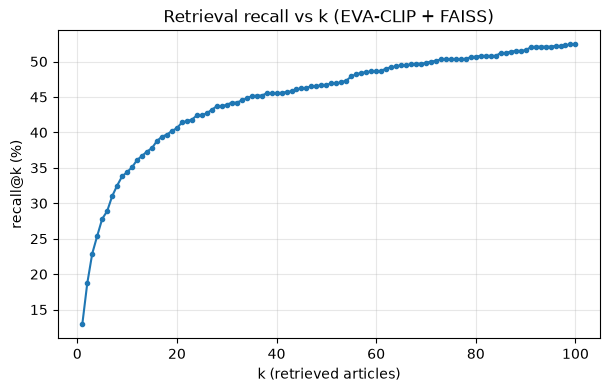

In [2]:
def recall_at(k):
    hit = 0
    for r in recs:
        g = norm(r['wikipedia_url'])
        cand = [norm(c['wiki_url']) for c in r['candidates'][:k]]
        if g and g in cand:
            hit += 1
    return hit / len(recs)

ks = list(range(1, maxk + 1))
curve = [recall_at(k) for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(ks, [100 * c for c in curve], marker='.')
plt.xlabel('k (retrieved articles)'); plt.ylabel('recall@k (%)')
plt.title('Retrieval recall vs k (EVA-CLIP + FAISS)'); plt.grid(alpha=0.3)
plt.show()

In [4]:
for k in [1, 3, 5, 10, 20, 30, 50, 60, 70, 80, 90, 100]:
    if k <= maxk:
        print('recall@%-3d %.1f%%' % (k, 100 * recall_at(k)))

recall@1   12.9%
recall@3   22.9%
recall@5   27.8%
recall@10  34.4%
recall@20  40.6%
recall@30  43.9%
recall@50  46.7%
recall@60  48.6%
recall@70  49.8%
recall@80  50.7%
recall@90  51.6%
recall@100 52.4%


## Reading it

- If the curve keeps climbing (recall@50 clearly above recall@5), **higher top-k + cross-encoder** is worth it — no reindex needed.
- If it flattens early (recall@50 barely above recall@5), the correct article simply isn't near the query in EVA-CLIP space → the **image encoder is the ceiling**. Then the levers are a domain-adapted / fine-tuned encoder (requires rebuilding the FAISS index) or a text-side retrieval channel (agentic, C).
- Whatever recall@k plateaus at is the **hard ceiling** for retrieval-grounded answering at that k: overall ≈ recall · acc_hit + (1−recall) · acc_miss.